# Spray Impingement on a Moving Piston — Prototype

Fuses the engineered-feature v2 MLP penetration model with the `piston/` mask builders.

**All tunable knobs live in the second cell ("ALL TUNABLE PARAMETERS")** — `RUN_DIR`, mesh fineness, cylinder geometry, piston design + parameters, piston motion, NN spray inputs, cone angle, time grid. Edit that one cell, then re-run cells below.

**Pipeline**
1. Imports + helper functions.
2. **Parameter cell** (single source of truth for all tunables).
3. Load MLP artifacts from `RUN_DIR`.
4. Build derived mesh (canvas, coordinate grids, wall mask).
5. Pick a piston design (`A` or `hermite`) and preview a midstroke mask.
6. Run the MLP across `t_start_ms` – `t_end_ms` to get $(\mu(t), \sigma(t))$.
7. Derive sin-crank piston motion `piston_offset(t)`.
8. PDF + cone guide-line helpers (with normalization sanity check).
9. Pre-render frames + per-frame collision probability $\int \text{piston\_mask}(x,y)\,p(x,y)\,dA$.
10. Animate piston + PDF + cone.
11. Plot collision probability vs time + cumulative integral.

Coordinate convention: `origin="upper"`, cylinder head at `y = 0`, injector at `(0, 0)`, radial axis = `x`, axial axis = `y` (positive downward toward piston).

In [2]:
# ── Imports + path setup + model-loading helpers ─────────────────────────────
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Patch
from IPython.display import HTML
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "MLP":
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in (PROJECT_ROOT, PROJECT_ROOT / "MLP", PROJECT_ROOT / "MLP" / "v2_engineered_feature"):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from engineered_feature_common import (
    TIME_FEATURE,
    build_dataset_registry,
    build_feature_matrix_np,
    infer_feature_family,
    load_run_artifacts,
)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = build_dataset_registry(PROJECT_ROOT / "test_matrix_json")


def split_model_outputs(model_output: torch.Tensor):
    mu_hat       = model_output[..., :1]
    log_var_hat  = model_output[..., 1:2]
    onset_logit  = model_output[..., 2:3] if model_output.shape[-1] >= 3 else None
    return mu_hat, log_var_hat, onset_logit


def predict_toy_physical(raw, time_ms):
    time_arr = np.atleast_1d(np.asarray(time_ms, dtype=np.float32))
    feats_np, a_scale_np, _ = build_feature_matrix_np(
        raw, time_arr, scaler_state, feature_columns, registry,
        time_feature=time_feature,
    )
    feats   = torch.as_tensor(feats_np, dtype=torch.float32, device=DEVICE)
    a_scale = torch.as_tensor(a_scale_np.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu_hat, log_var_hat, onset_logit = split_model_outputs(model(feats))
        log_var_hat = torch.clamp(log_var_hat, min=-20.0, max=20.0)
        std_floor   = float(train_config.get("std_clamp_min", 0.0))
        mu_phys     = (a_scale * mu_hat).cpu().numpy().reshape(-1)
        std_phys    = torch.clamp(a_scale * torch.exp(0.5 * log_var_hat), min=std_floor)
        std_phys    = std_phys.cpu().numpy().reshape(-1)
    onset_prob = (
        torch.sigmoid(onset_logit).cpu().numpy().reshape(-1)
        if onset_logit is not None else None
    )
    return {"mu_np": mu_phys, "std_np": std_phys, "onset_prob_np": onset_prob}


print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# ── ALL TUNABLE PARAMETERS ───────────────────────────────────────────────────
# Edit this single cell to drive the whole notebook. Re-run cells below
# (or "Run All Below") to apply changes.

# ─── Model artifacts ────────────────────────────────────────────────────────
RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "distill_cdf_onset_v2_20260410_103413"

# ─── Mesh fineness + cylinder geometry ──────────────────────────────────────
grid_size       = 0.25       # mm/px  (smaller = finer PDF, slower animation)
cylinder_radius = 120.0      # mm     (= r_bore)
right_padding   = 5.0        # mm     (extra canvas right of bore wall)
canvas_h_mm     = 200.0      # mm     (axial extent — must hold piston BDC + height)

# ─── Piston design selection ────────────────────────────────────────────────
PISTON_DESIGN = "A"          # "A"  or  "hermite"

piston_a_params = dict(      # Design A — bowl piston via radii
    r_bore=cylinder_radius,
    r_outer_bowl=100.0, r_topland=5.0, r_ring=15.0,        # 100+5+15 = 120 ✓
    r_inner_bowl=80.0,  r_lip=15.0,    r_floor=5.0,         # 80+15+5  = 100 ✓
    r_center_circle=0.0,
    h_vertical=10.0,    piston_height=30.0,                 # 10+15+5  = 30  ✓
)

hermite_params = dict(       # Hermite — quintic spline crown profile
    r_bore=cylinder_radius,
    r_topland=5.0,
    piston_height=30.0,
    ctrl_pts_mm=np.array([
        [  0.0,  3.0],
        [ 55.0, 14.0],
        [100.0,  2.0],
        [115.0,  0.0],
    ], dtype=float),
    ctrl_vels=np.array([
        [33.0,  0.0],
        [28.0,  0.0],
        [ 9.0, -3.0],
        [ 4.5, -0.5],
    ], dtype=float),
)

# ─── Piston motion (slider-crank approximation) ─────────────────────────────
RPM             = 1500.0
stroke_half     = 30.0       # mm  (peak excursion of crown about its mean)
offset_baseline = 75.0       # mm  (mean crown y position from cylinder head)
crank_phase_deg = 0.0        # deg (0 → t=0 at TDC; 180 → t=0 at BDC)

# ─── Spray inputs (neural-network features + cone) ──────────────────────────
toy_raw = {
    "tilt_angle_radian":         float(np.deg2rad(20.0)),  # spray vs radial
    "plumes":                    10.0,
    "diameter_mm":               0.34,
    "injection_duration_us":     800.0,
    "injection_pressure_bar":    2000.0,
    "ambient_pressure_bar_phys": 15.0,
    "chamber_pressure_bar":      15.0,
    "control_backpressure_bar":  4.0,
}
cone_angle_deg = 20.0        # deg  constant input (out of paper scope)
INJECTOR_XY    = (0.0, 0.0)  # mm   spray origin in canvas coords

# ─── Time grid (model evaluation + animation) ───────────────────────────────
n_frames   = 60
t_start_ms = 0.0
t_end_ms   = 5.0

In [4]:
# ── Load MLP artifacts (uses RUN_DIR from the parameter cell above) ──────────
artifacts = load_run_artifacts(RUN_DIR, device=DEVICE)

model           = artifacts.model
scaler_state    = artifacts.scaler_state
train_config    = artifacts.train_config
feature_columns = list(train_config["feature_columns"])
time_feature    = str(train_config.get("time_feature", TIME_FEATURE))
feature_family  = infer_feature_family(feature_columns)
if feature_family != "engineered_v2":
    raise RuntimeError(f"Expected engineered_v2 features, got {feature_family!r}")

print(f"Model loaded from {RUN_DIR.name}")
print(f"Feature columns: {feature_columns}")
print(f"Output dim: {train_config.get('output_dim', 2)}")

Model loaded from distill_cdf_onset_v2_20260410_103413
Feature columns: ['time_norm_0_5ms', 'tilt_angle_radian_z', 'plumes_z', 'injection_duration_us_z', 'control_backpressure_bar_z']
Output dim: 3


In [5]:
# ── Derived mesh (uses grid_size, cylinder_radius, … from the parameter cell) ─
canvas_w_mm = cylinder_radius + right_padding
canvas_w_px = int(round(canvas_w_mm / grid_size))
canvas_h_px = int(round(canvas_h_mm / grid_size))
canvas      = np.zeros((canvas_h_px, canvas_w_px), dtype=np.uint8)


def mm_to_grid_index(value_mm: float, mode: str = "round") -> int:
    s = float(value_mm) / float(grid_size)
    if mode == "round":
        return int(np.rint(s))
    if mode == "floor":
        return int(np.floor(s + 1e-9))
    if mode == "ceil":
        return int(np.ceil(s - 1e-9))
    raise ValueError(f"Unsupported mode: {mode!r}")


# Static wall mask (cylinder side wall — does not move)
wall_mask = np.zeros_like(canvas, dtype=bool)
wall_mask[:, mm_to_grid_index(cylinder_radius):] = True

# Coordinate grids (mm) — used by the PDF builder later
x_axis = np.arange(canvas_w_px, dtype=float) * grid_size
y_axis = np.arange(canvas_h_px, dtype=float) * grid_size
X, Y   = np.meshgrid(x_axis, y_axis, indexing="xy")

print(f"Canvas: {canvas_w_mm} x {canvas_h_mm} mm  →  {canvas_w_px} x {canvas_h_px} px")
print(f"Grid:   {grid_size} mm/px  ({grid_size**2:.4f} mm² per cell)")

Canvas: 125.0 x 200.0 mm  →  500 x 800 px
Grid:   0.25 mm/px  (0.0625 mm² per cell)


Piston design = 'A', mask area = 13601.4 mm²


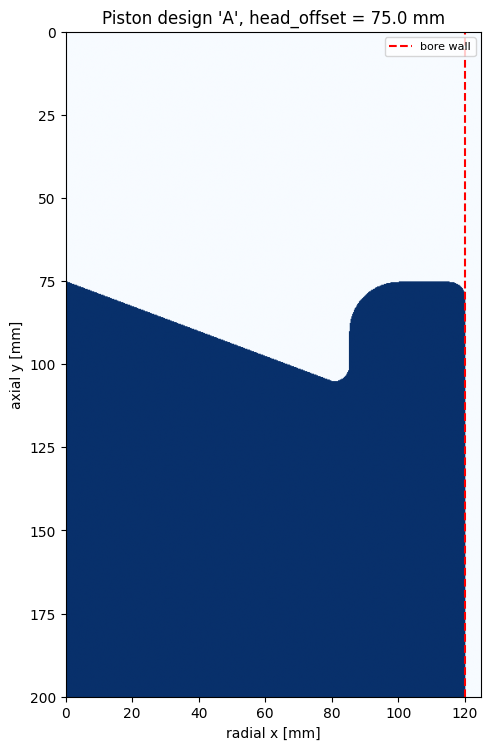

In [6]:
# ── Piston dispatcher (uses PISTON_DESIGN + *_params from the parameter cell) ─
from piston.design_A       import piston_design_A
from piston.design_hermite import piston_design_hermite

piston_height = float(piston_a_params["piston_height"])
assert piston_height == hermite_params["piston_height"], "piston_height must match across designs"


def make_piston_mask(cylinder_head_offset: float) -> np.ndarray:
    if PISTON_DESIGN == "A":
        return piston_design_A(
            canvas, grid_size,
            cylinder_head_offset=cylinder_head_offset,
            **piston_a_params,
        )
    if PISTON_DESIGN == "hermite":
        return piston_design_hermite(
            canvas, grid_size,
            cylinder_head_offset=cylinder_head_offset,
            **hermite_params,
        )
    raise ValueError(f"Unknown PISTON_DESIGN={PISTON_DESIGN!r}")


# Quick sanity render at a midstroke offset
_test_offset = 75.0
_test_mask   = make_piston_mask(_test_offset)
print(f"Piston design = {PISTON_DESIGN!r}, mask area = {_test_mask.sum() * grid_size**2:.1f} mm²")

fig_test, ax_test = plt.subplots(figsize=(canvas_w_mm/25, canvas_h_mm/25))
ax_test.imshow(_test_mask, cmap="Blues", aspect="equal",
               extent=[0, canvas_w_mm, canvas_h_mm, 0], origin="upper")
ax_test.axvline(cylinder_radius, color="red", linestyle="--", label="bore wall")
ax_test.set_xlabel("radial x [mm]"); ax_test.set_ylabel("axial y [mm]")
ax_test.set_title(f"Piston design {PISTON_DESIGN!r}, head_offset = {_test_offset} mm")
ax_test.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# ── Run model on the time grid (uses toy_raw, n_frames, t_*_ms from params) ──
tilt        = float(toy_raw["tilt_angle_radian"])
toy_time_ms = np.linspace(t_start_ms, t_end_ms, n_frames, dtype=np.float32)

prediction      = predict_toy_physical(toy_raw, toy_time_ms)
mu_arr          = prediction["mu_np"]
std_arr         = prediction["std_np"]
onset_prob_arr  = prediction["onset_prob_np"]

print(f"mu  range: {mu_arr.min():.2f} – {mu_arr.max():.2f} mm")
print(f"std range: {std_arr.min():.2f} – {std_arr.max():.2f} mm")
if onset_prob_arr is not None:
    print(f"onset prob range: {onset_prob_arr.min():.3f} – {onset_prob_arr.max():.3f}")

mu  range: -0.07 – 118.89 mm
std range: 1.81 – 14.75 mm
onset prob range: 0.112 – 1.000


In [8]:
# ── Derived piston motion (uses RPM, stroke_half, offset_baseline, phase) ────
omega_rad_per_s  = 2 * np.pi * RPM / 60.0
omega_rad_per_ms = omega_rad_per_s / 1000.0
phase_rad        = np.deg2rad(crank_phase_deg)


def piston_offset(t_ms):
    return offset_baseline - stroke_half * np.cos(omega_rad_per_ms * t_ms + phase_rad)


offsets_preview = piston_offset(toy_time_ms)
print(f"Crown offset over {t_start_ms}–{t_end_ms} ms: "
      f"{offsets_preview.min():.1f} – {offsets_preview.max():.1f} mm")
print(f"Piston bottom over {t_start_ms}–{t_end_ms} ms: "
      f"{(offsets_preview + piston_height).min():.1f} – "
      f"{(offsets_preview + piston_height).max():.1f} mm  (canvas h = {canvas_h_mm})")

Crown offset over 0.0–5.0 ms: 45.0 – 53.8 mm
Piston bottom over 0.0–5.0 ms: 75.0 – 83.8 mm  (canvas h = 200.0)


In [9]:
# ── PDF builder + cone guide-line helper ─────────────────────────────────────
def gaussian_2d_rotated(X, Y, x0, y0, sigma_axis, sigma_ortho, theta):
    c = np.cos(theta); s = np.sin(theta)
    dx = X - x0;       dy = Y - y0
    u  =  c * dx + s * dy   # along spray axis
    v  = -s * dx + c * dy   # orthogonal
    return np.exp(-0.5 * ((u / sigma_axis) ** 2 + (v / sigma_ortho) ** 2)) / (
        2.0 * np.pi * sigma_axis * sigma_ortho
    )


def cone_guide_endpoints(injector_xy, tilt_rad, half_cone_rad, length_mm):
    """Return ((x0,y0)→(x1_lo,y1_lo), (x0,y0)→(x1_hi,y1_hi)) as two line segments."""
    x0, y0 = injector_xy
    a_lo, a_hi = tilt_rad - half_cone_rad, tilt_rad + half_cone_rad
    return (
        (x0, y0, x0 + length_mm * np.cos(a_lo), y0 + length_mm * np.sin(a_lo)),
        (x0, y0, x0 + length_mm * np.cos(a_hi), y0 + length_mm * np.sin(a_hi)),
    )


half_cone_rad = np.deg2rad(cone_angle_deg / 2.0)

# Sanity: build a single PDF at the largest mu and check normalization
_mu  = float(mu_arr[-1])
_sd  = max(float(std_arr[-1]), 1e-3)
_so  = max(_mu * np.tan(half_cone_rad) / 3.0, 1e-3)
_x0  = INJECTOR_XY[0] + _mu * np.cos(tilt)
_y0  = INJECTOR_XY[1] + _mu * np.sin(tilt)
_pdf = gaussian_2d_rotated(X, Y, _x0, _y0, _sd, _so, tilt)
_pdf /= _pdf.sum() * grid_size ** 2 + 1e-30
print(f"Sanity: PDF integrates to {_pdf.sum() * grid_size**2:.4f}  (target ≈ 1.0)")

Sanity: PDF integrates to 1.0000  (target ≈ 1.0)


In [10]:
# ── Pre-render all frames + per-frame collision probability ──────────────────
piston_frames  = []
pdf_frames     = []
collision_prob = np.zeros(n_frames, dtype=float)

for i, t_ms in enumerate(toy_time_ms):
    pmask  = make_piston_mask(float(piston_offset(t_ms)))
    mu, sd = float(mu_arr[i]), max(float(std_arr[i]), 1e-3)
    sg_o   = max(mu * np.tan(half_cone_rad) / 3.0, 1e-3)
    x0     = INJECTOR_XY[0] + mu * np.cos(tilt)
    y0     = INJECTOR_XY[1] + mu * np.sin(tilt)
    pdf    = gaussian_2d_rotated(X, Y, x0, y0, sd, sg_o, tilt)
    pdf   /= pdf.sum() * grid_size ** 2 + 1e-30
    piston_frames.append(pmask)
    pdf_frames.append(pdf)
    collision_prob[i] = float((pmask * pdf).sum() * grid_size ** 2)

# Sanity checks
assert (collision_prob >= 0).all() and (collision_prob <= 1.0 + 1e-6).all(), collision_prob
print(f"Rendered {n_frames} frames.")
print(f"Collision probability range: {collision_prob.min():.3e} – {collision_prob.max():.3e}")
print(f"Peak collision at t = {toy_time_ms[np.argmax(collision_prob)]:.2f} ms")

Rendered 60 frames.
Collision probability range: 0.000e+00 – 3.709e-02
Peak collision at t = 3.47 ms


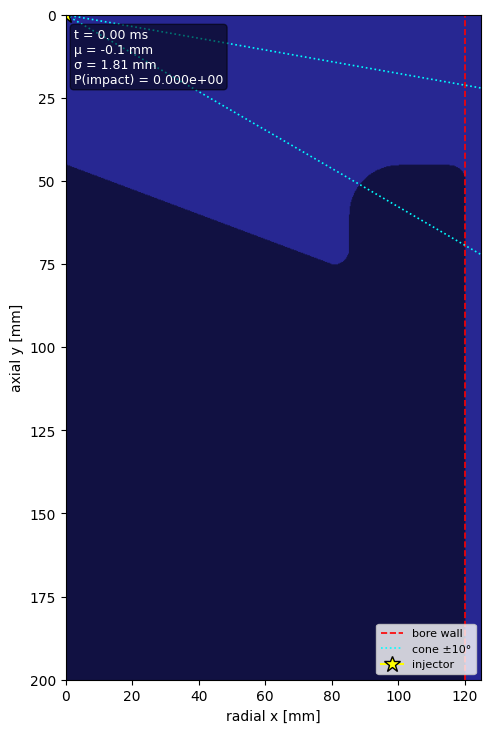

In [11]:
# ── Animate piston + spray PDF + cone guide lines ────────────────────────────
scale = 25
fig, ax = plt.subplots(figsize=(canvas_w_mm / scale, canvas_h_mm / scale))

extent     = [0.0, canvas_w_mm, canvas_h_mm, 0.0]
pdf_vmax   = max(p.max() for p in pdf_frames)

im_pdf    = ax.imshow(pdf_frames[0], cmap="jet", origin="upper", extent=extent,
                      aspect="equal", vmin=0.0, vmax=pdf_vmax, alpha=0.85)
piston_overlay = np.ma.masked_where(~piston_frames[0], piston_frames[0].astype(float))
im_piston = ax.imshow(piston_overlay, cmap="gray_r", origin="upper", extent=extent,
                      aspect="equal", vmin=0.0, vmax=1.0, alpha=0.55)

ax.axvline(cylinder_radius, color="red", linestyle="--", linewidth=1.2, label="bore wall")

guide_len = float(np.hypot(canvas_w_mm, canvas_h_mm))
(lo_seg, hi_seg) = cone_guide_endpoints(INJECTOR_XY, tilt, half_cone_rad, guide_len)
ax.plot([lo_seg[0], lo_seg[2]], [lo_seg[1], lo_seg[3]], color="cyan",
        linestyle=":", linewidth=1.2, label=f"cone ±{cone_angle_deg/2:.0f}°")
ax.plot([hi_seg[0], hi_seg[2]], [hi_seg[1], hi_seg[3]], color="cyan",
        linestyle=":", linewidth=1.2)
ax.plot(*INJECTOR_XY, marker="*", color="yellow", markeredgecolor="k",
        markersize=12, label="injector")

ax.set_xlim(0, canvas_w_mm)
ax.set_ylim(canvas_h_mm, 0)   # invert for origin='upper'
ax.set_xlabel("radial x [mm]")
ax.set_ylabel("axial y [mm]")
ax.legend(loc="lower right", fontsize=8)

info_text = ax.text(0.02, 0.98, "", transform=ax.transAxes,
                    fontsize=9, color="white", va="top",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.55))


def update(i):
    im_pdf.set_data(pdf_frames[i])
    overlay = np.ma.masked_where(~piston_frames[i], piston_frames[i].astype(float))
    im_piston.set_data(overlay)
    info_text.set_text(
        f"t = {toy_time_ms[i]:.2f} ms\n"
        f"μ = {mu_arr[i]:.1f} mm\n"
        f"σ = {std_arr[i]:.2f} mm\n"
        f"P(impact) = {collision_prob[i]:.3e}"
    )
    return im_pdf, im_piston, info_text


ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=1000.0/30.0, blit=False)
plt.tight_layout()
HTML(ani.to_jshtml())

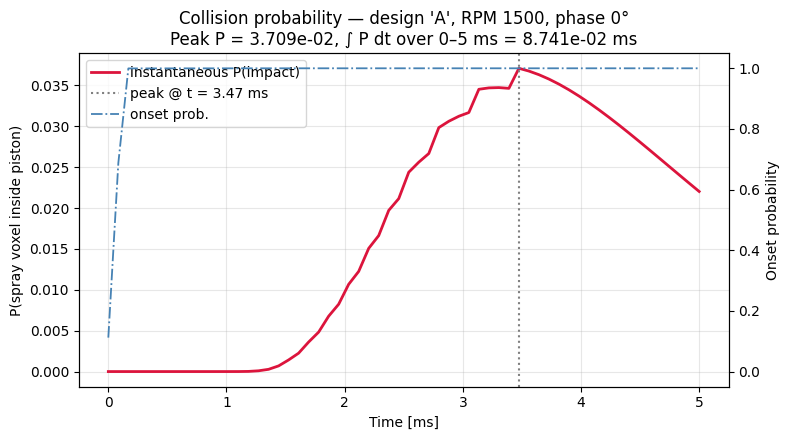

Peak collision P:           3.709157e-02
Time of peak:               3.475 ms
Trapezoidal ∫P dt (0–5 ms): 8.740514e-02 ms


In [12]:
# ── Collision probability over time + cumulative integral ────────────────────
cum_prob = np.cumsum(0.5 * (collision_prob[:-1] + collision_prob[1:]) *
                     np.diff(toy_time_ms))

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
ax2.plot(toy_time_ms, collision_prob, color="crimson", lw=2,
         label="instantaneous P(impact)")
i_peak = int(np.argmax(collision_prob))
ax2.axvline(toy_time_ms[i_peak], color="gray", ls=":",
            label=f"peak @ t = {toy_time_ms[i_peak]:.2f} ms")
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("P(spray voxel inside piston)")
ax2.grid(alpha=0.3)

if onset_prob_arr is not None:
    ax2_r = ax2.twinx()
    ax2_r.plot(toy_time_ms, onset_prob_arr, color="steelblue",
               linestyle="-.", lw=1.3, label="onset prob.")
    ax2_r.set_ylabel("Onset probability")
    ax2_r.set_ylim(-0.05, 1.05)
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2_r.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper left")
else:
    ax2.legend(loc="upper left")

ax2.set_title(
    f"Collision probability — design {PISTON_DESIGN!r}, RPM {RPM:.0f}, "
    f"phase {crank_phase_deg:.0f}°\n"
    f"Peak P = {collision_prob[i_peak]:.3e}, "
    f"∫ P dt over 0–5 ms = {cum_prob[-1]:.3e} ms"
)
plt.tight_layout(); plt.show()

print(f"Peak collision P:           {collision_prob[i_peak]:.6e}")
print(f"Time of peak:               {toy_time_ms[i_peak]:.3f} ms")
print(f"Trapezoidal ∫P dt (0–5 ms): {cum_prob[-1]:.6e} ms")